# Technical Test - Descartes Underwriting

## Ulysse DEMAY

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

## Preprocessing

In [3]:
train_set = pd.read_csv('train_auto.csv', sep=',')
test_set = pd.read_csv('test_auto.csv', sep=',')

In [4]:
train_set.head()

,INDEX,TARGET_FLAG,TARGET_AMT,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,...,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
0,1,0,0.0,0,60.0,0,11.0,"$67,349",No,$0,...,"$14,230",11,Minivan,yes,"$4,461",2,No,3,18.0,Highly Urban/ Urban
1,2,0,0.0,0,43.0,0,11.0,"$91,449",No,"$257,252",...,"$14,940",1,Minivan,yes,$0,0,No,0,1.0,Highly Urban/ Urban
2,4,0,0.0,0,35.0,1,10.0,"$16,039",No,"$124,191",...,"$4,010",4,z_SUV,no,"$38,690",2,No,3,10.0,Highly Urban/ Urban
3,5,0,0.0,0,51.0,0,14.0,NaN,No,"$306,251",...,"$15,440",7,Minivan,yes,$0,0,No,0,6.0,Highly Urban/ Urban
4,6,0,0.0,0,50.0,0,NaN,"$114,986",No,"$243,925",...,"$18,000",1,z_SUV,no,"$19,217",2,Yes,3,17.0,Highly Urban/ Urban


First we remove the columns that won't be useful for the use-case : INDEX and TARGET_AMT (since it is not available in the test set).

In [5]:
train_set.drop(columns=['INDEX', 'TARGET_AMT'], inplace=True)

### Column format transformation

Then we transform the amount format to the classical float format.

In [6]:
# amount transformation to float
train_set['INCOME'] = pd.to_numeric(train_set['INCOME'].str.replace('$', '').str.replace(',', ''))
train_set['HOME_VAL'] = pd.to_numeric(train_set['HOME_VAL'].str.replace('$', '').str.replace(',', ''))
train_set['BLUEBOOK'] = pd.to_numeric(train_set['BLUEBOOK'].str.replace('$', '').str.replace(',', ''))
train_set['OLDCLAIM'] = pd.to_numeric(train_set['OLDCLAIM'].str.replace('$', '').str.replace(',', ''))

### Missing values processing

In [7]:
# rows presenting at least a missing value
train_set[train_set.isna().any(axis=1)]

,TARGET_FLAG,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,SEX,...,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
3,0,0,51.0,0,14.0,NaN,No,306251.0,Yes,M,...,15440,7,Minivan,yes,0,0,No,0,6.0,Highly Urban/ Urban
4,0,0,50.0,0,NaN,114986.0,No,243925.0,Yes,z_F,...,18000,1,z_SUV,no,19217,2,Yes,3,17.0,Highly Urban/ Urban
6,0,0,54.0,0,NaN,18755.0,No,NaN,Yes,z_F,...,8780,1,z_SUV,no,0,0,No,0,1.0,Highly Urban/ Urban
7,1,1,37.0,2,NaN,107961.0,No,333680.0,Yes,M,...,16970,1,Van,yes,2374,1,Yes,10,7.0,Highly Urban/ Urban
13,1,0,53.0,0,11.0,130795.0,No,0.0,z_No,M,...,28340,6,Panel Truck,yes,0,0,No,3,10.0,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8133,1,0,47.0,0,13.0,282198.0,No,649247.0,z_No,M,...,34420,11,Panel Truck,yes,0,0,Yes,2,16.0,Highly Urban/ Urban
8134,1,0,43.0,0,NaN,0.0,No,55203.0,Yes,z_F,...,24030,9,Minivan,no,3035,4,No,0,14.0,Highly Urban/ Urban
8136,0,0,32.0,2,14.0,NaN,No,219966.0,Yes,M,...,19680,10,Van,no,0,0,No,1,9.0,z_Highly Rural/ Rural
8140,0,0,56.0,0,11.0,12917.0,No,NaN,z_No,z_F,...,2790,4,z_SUV,no,0,0,No,0,12.0,Highly Urban/ Urban


As we can see, there are more than 2000 rows containing a missing value. As a result, we have to keep these rows and choose strategies to fill these missing values.

In [8]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8161 entries, 0 to 8160
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TARGET_FLAG  8161 non-null   int64  
 1   KIDSDRIV     8161 non-null   int64  
 2   AGE          8155 non-null   float64
 3   HOMEKIDS     8161 non-null   int64  
 4   YOJ          7707 non-null   float64
 5   INCOME       7716 non-null   float64
 6   PARENT1      8161 non-null   object 
 7   HOME_VAL     7697 non-null   float64
 8   MSTATUS      8161 non-null   object 
 9   SEX          8161 non-null   object 
 10  EDUCATION    8161 non-null   object 
 11  JOB          7635 non-null   object 
 12  TRAVTIME     8161 non-null   int64  
 13  CAR_USE      8161 non-null   object 
 14  BLUEBOOK     8161 non-null   int64  
 15  TIF          8161 non-null   int64  
 16  CAR_TYPE     8161 non-null   object 
 17  RED_CAR      8161 non-null   object 
 18  OLDCLAIM     8161 non-null   int64  
 19  CLM_FR

In order to fill the missing values, the strategy chosen will be the following :
- AGE, YOJ, HOME_VAL, CAR_AGE : we fill with the mean of each column ;
- JOB : we add a "NotAvailable" category. We could have thought that these people are unemployed but lot of them have an income so this hypothesis may be false ;
- INCOME : we fill the missing values of this column with a mean considered for each category of JOB.

One should note that this strategy can be changed and that results could be compared for each strategy chosen. In addition, explanations of the client (or someone knowing precisely what is behind the data collected) could conduct to another strategy, or even the removal of rows where the value of a precise column is missing. 

In [9]:
train_set[['AGE', 'YOJ', 'HOME_VAL', 'CAR_AGE']] = train_set[['AGE', 'YOJ', 'HOME_VAL', 'CAR_AGE']].fillna(value=train_set[['AGE', 'YOJ', 'HOME_VAL', 'CAR_AGE']].mean())
train_set['JOB'] = train_set['JOB'].fillna(value='NotAvailable')
train_set['INCOME'] = train_set['INCOME'].fillna(train_set.groupby('JOB')['INCOME'].transform('mean'))

In [10]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8161 entries, 0 to 8160
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TARGET_FLAG  8161 non-null   int64  
 1   KIDSDRIV     8161 non-null   int64  
 2   AGE          8161 non-null   float64
 3   HOMEKIDS     8161 non-null   int64  
 4   YOJ          8161 non-null   float64
 5   INCOME       8161 non-null   float64
 6   PARENT1      8161 non-null   object 
 7   HOME_VAL     8161 non-null   float64
 8   MSTATUS      8161 non-null   object 
 9   SEX          8161 non-null   object 
 10  EDUCATION    8161 non-null   object 
 11  JOB          8161 non-null   object 
 12  TRAVTIME     8161 non-null   int64  
 13  CAR_USE      8161 non-null   object 
 14  BLUEBOOK     8161 non-null   int64  
 15  TIF          8161 non-null   int64  
 16  CAR_TYPE     8161 non-null   object 
 17  RED_CAR      8161 non-null   object 
 18  OLDCLAIM     8161 non-null   int64  
 19  CLM_FR

### Categorical features processing

The goal of this section is to transform categorical features to numerical features, that can be handled by most of machine learning algorithm.

In [11]:
cat_cols = ['PARENT1',  # binary
            'MSTATUS',  # binary
            'SEX',  # binary
            'EDUCATION',
            'JOB',
            'CAR_USE',  # binary
            'CAR_TYPE',
            'RED_CAR',  # binary
            'REVOKED',  # binary
            'URBANICITY']  # binary

In [12]:
train_set['PARENT1'].value_counts()

No     7084
Yes    1077
Name: PARENT1, dtype: int64

In [13]:
train_set['MSTATUS'].value_counts()

Yes     4894
z_No    3267
Name: MSTATUS, dtype: int64

In [14]:
train_set['SEX'].value_counts()

z_F    4375
M      3786
Name: SEX, dtype: int64

In [15]:
train_set['EDUCATION'].value_counts()

z_High School    2330
Bachelors        2242
Masters          1658
<High School     1203
PhD               728
Name: EDUCATION, dtype: int64

In [16]:
train_set['JOB'].value_counts()

z_Blue Collar    1825
Clerical         1271
Professional     1117
Manager           988
Lawyer            835
Student           712
Home Maker        641
NotAvailable      526
Doctor            246
Name: JOB, dtype: int64

In [17]:
train_set['CAR_USE'].value_counts()

Private       5132
Commercial    3029
Name: CAR_USE, dtype: int64

In [18]:
train_set['CAR_TYPE'].value_counts()

z_SUV          2294
Minivan        2145
Pickup         1389
Sports Car      907
Van             750
Panel Truck     676
Name: CAR_TYPE, dtype: int64

In [19]:
train_set['RED_CAR'].value_counts()

no     5783
yes    2378
Name: RED_CAR, dtype: int64

In [20]:
train_set['REVOKED'].value_counts()

No     7161
Yes    1000
Name: REVOKED, dtype: int64

In [21]:
train_set['URBANICITY'].value_counts()

Highly Urban/ Urban      6492
z_Highly Rural/ Rural    1669
Name: URBANICITY, dtype: int64

It seems that there is no big imbalance all along these features so we can reasonnably keep them (provided there is not too much missing values) and use an OneHotEncoder so they will be handled most of classifiers. Note that since there is no order relation between the values of our categorical features, we don't use an OrdinalEncoder.

In [22]:
ohe = OneHotEncoder(sparse=False)
train_set_cat_array = ohe.fit_transform(train_set[['PARENT1', 'MSTATUS', 'SEX', 'EDUCATION', 'JOB', 'CAR_USE',
                                                  'CAR_TYPE', 'RED_CAR', 'REVOKED', 'URBANICITY']])
# train_set[cat_cols] = pd.DataFrame(train_set_cat, columns=cat_cols, dtype='int64')

### Correlation Matrix

Plotting the correlation matrix can be a first step for the feature selection, i.e. the removal of some features that are not relevant to predict the TARGET_FLAG. Indeed, these features not extremely linked with the flag we want to predict can decrease our model's performances and inrease the training time.

In [23]:
not_cat_cols = list(set(train_set.columns) - set(cat_cols))

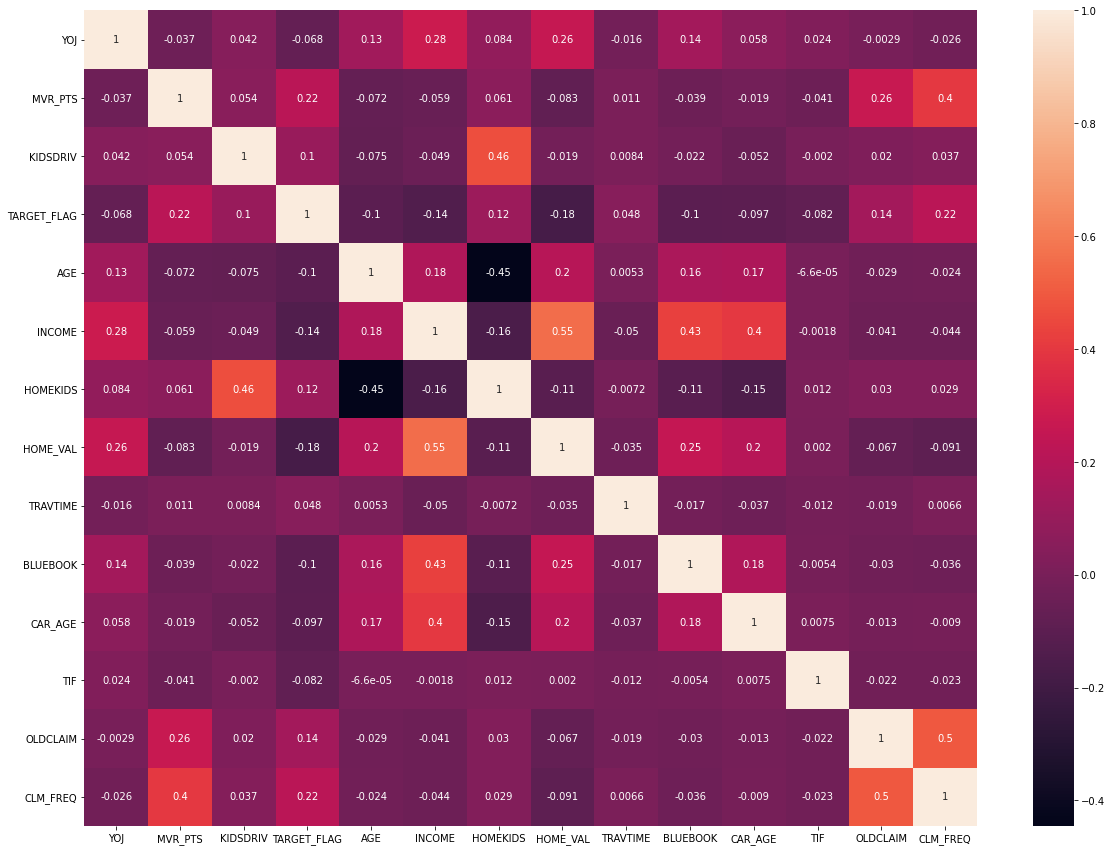

In [24]:
corr_matrix = train_set[not_cat_cols].corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=True)
plt.show()

We can reasonnably assume that the features presenting a correlation between -0.01 and +0.01 with the TARGET_FLAG are not really linked with it, so not extremely useful for the predicition.

In [25]:
not_relevant_cols = ['CAR_AGE', 'YOJ', 'TRAVTIME', 'TIF']

In [26]:
relevant_not_cat_cols = list(set(not_cat_cols) - set(not_relevant_cols) - {'TARGET_FLAG'})

**Important :** Since we plan to use a XGBoost Classifier, that can handle lot of features, we could try to keep these features to see if it improves the result.

### Classes distribution

<AxesSubplot:>

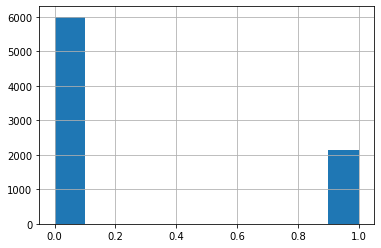

In [27]:
train_set['TARGET_FLAG'].hist()

As we can see, the binary classification problem is quite imbalanced. As a result, it should be interesting to use metrics such as F1 score since this 1/4 - 3/4 labels distribution could fool the precision.

## Model training and evaluation

In [39]:
cat_cols

['PARENT1',
 'MSTATUS',
 'SEX',
 'EDUCATION',
 'JOB',
 'CAR_USE',
 'CAR_TYPE',
 'RED_CAR',
 'REVOKED',
 'URBANICITY']

In [28]:
# obtention of the train set as an array and the labels as an array too
X = np.concatenate([train_set[relevant_not_cat_cols].to_numpy(), train_set_cat_array], axis=1)
y = train_set['TARGET_FLAG'].to_numpy()

In [29]:
# train and test split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=12)

### Decision Tree Classifier

In [30]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
y_pred_rf = rf_classifier.predict(X_valid)
print("Random Forest F1 score on the validation set :", f1_score(y_valid, y_pred_rf))

Random Forest F1 score on the validation set : 0.4828934506353861


### XGBoost Classifier

In [32]:
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [33]:
y_pred_xgb = xgb_classifier.predict(X_valid)
print("XGBoost F1 score on the validation set :", f1_score(y_valid, y_pred_xgb))

XGBoost F1 score on the validation set : 0.5246478873239436


At first sight, without any hyperparameter tuning, it seems that the XGBoost algorithm for classification returns the best results. As a result, we could focus our study on this algorithm and use a RandomizedSearchCV and a GridSearchCV to choose the best hyperparameters.

We can also perform a feature importance to visualize the importance of each feature used to train our XGBoost Classifier. This short analysis can be useful to have a better idea of which feature matters the most to predict the TARGET_FLAG.

<AxesSubplot:title={'center':'Feature importance'}, xlabel='F score', ylabel='Features'>

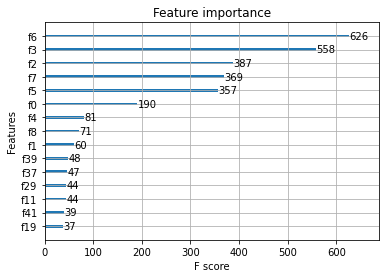

In [34]:
xgb.plot_importance(xgb_classifier, max_num_features=15)

The feature importance plot doesn't provide features names since we lose it when converting the DataFrame to a matrix. However, they can easily be found by reading the notebook. Basically, we can provide them again :
- 0. 'MVR_PTS',
- 1. 'KIDSDRIV',
- 2. 'AGE',
- 3. 'INCOME',
- 4. 'HOMEKIDS',
- 5. 'HOME_VAL',
- 6. 'BLUEBOOK',
- 7. 'OLDCLAIM',
- 8. 'CLM_FREQ',
- 9 to 10. 'PARENT1',
- 11 to 12. 'MSTATUS',
- 13 to 14. 'SEX',
- 15 to 19. 'EDUCATION',
- 20 to 28. 'JOB',
- 29 to 30. 'CAR_USE',
- 31 to 36. 'CAR_TYPE',
- 37 to 38. 'RED_CAR',
- 39 to 40. 'REVOKED',
- 41 to 42. 'URBANICITY'.

## Predictions

This part aims at creating the `predictions.csv` file.

In [290]:
test_set = pd.read_csv('test_auto.csv', sep=',')

In [291]:
# test_set processing
INDEX = test_set['INDEX']
test_set.drop(columns=['INDEX', 'TARGET_AMT', 'TARGET_FLAG'], inplace=True)

# amount transformation to float
test_set['INCOME'] = pd.to_numeric(test_set['INCOME'].str.replace('$', '').str.replace(',', ''))
test_set['HOME_VAL'] = pd.to_numeric(test_set['HOME_VAL'].str.replace('$', '').str.replace(',', ''))
test_set['BLUEBOOK'] = pd.to_numeric(test_set['BLUEBOOK'].str.replace('$', '').str.replace(',', ''))
test_set['OLDCLAIM'] = pd.to_numeric(test_set['OLDCLAIM'].str.replace('$', '').str.replace(',', ''))

# fill missing values (note that we have to use the means found on the train_set)
test_set[['AGE', 'YOJ', 'HOME_VAL', 'CAR_AGE']] = test_set[['AGE', 'YOJ', 'HOME_VAL', 'CAR_AGE']].fillna(value=train_set[['AGE', 'YOJ', 'HOME_VAL', 'CAR_AGE']].mean())
test_set['JOB'] = test_set['JOB'].fillna(value='NotAvailable')
test_set['INCOME'] = test_set['INCOME'].fillna(train_set.groupby('JOB')['INCOME'].transform('mean'))

# categorical variables transformation using the OneHotEncoder fit on the train_set
test_set_cat_array = ohe.transform(test_set[['PARENT1', 'MSTATUS', 'SEX', 'EDUCATION', 'JOB', 'CAR_USE',
                                              'CAR_TYPE', 'RED_CAR', 'REVOKED', 'URBANICITY']])

In [292]:
# obtention of the test set as an array
X_test = np.concatenate([test_set[relevant_not_cat_cols].to_numpy(), test_set_cat_array], axis=1)

In [293]:
# prediction on the test set
y_pred_test = xgb_classifier.predict(X_test)

In [296]:
pred_df = pd.DataFrame({'INDEX':INDEX.to_numpy(), 'TARGET_FLAG':y_pred_test})

In [298]:
pred_df.to_csv('predictions.csv', index=False)